In [13]:
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple
import matplotlib.pyplot as plt

Data class model init

In [14]:
Edge = Tuple[int, int]

@dataclass(frozen=True)
class Fragment:
    n_sites: int
    edges: List[Edge]
    t: float
    eps: np.ndarray   # on-site energies

In [15]:
N = 6
t = 1.0

# On-site energies (graphene ideal = 0)
eps = np.zeros(N)

edges = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,0)]

fragment = Fragment(
    n_sites=N,
    edges=edges,
    t=t,
    eps=eps
)


Validation for fragment

In [16]:
def validate_fragment(fragment: Fragment):
    N = fragment.n_sites
    for i, j in fragment.edges:
        if not (0 <= i < N and 0 <= j < N):
            raise ValueError(f"Edge {(i,j)} invalid")
        if i == j:
            raise ValueError("Self-loop not allowed")
    if len(fragment.eps) != N:
        raise ValueError("eps length must equal n_sites")

validate_fragment(fragment)
print("Fragment validated.")

Fragment validated.


In [17]:
def build_hamiltonian(fragment: Fragment):
    N = fragment.n_sites
    H = np.zeros((N, N), dtype=float)

    # Diagonal (on-site energies)
    np.fill_diagonal(H, fragment.eps)

    # Off-diagonal hopping
    for i, j in fragment.edges:
        H[i, j] = -fragment.t
        H[j, i] = -fragment.t

    return H

H = build_hamiltonian(fragment)
H

array([[ 0., -1.,  0.,  0.,  0., -1.],
       [-1.,  0., -1.,  0.,  0.,  0.],
       [ 0., -1.,  0., -1.,  0.,  0.],
       [ 0.,  0., -1.,  0., -1.,  0.],
       [ 0.,  0.,  0., -1.,  0., -1.],
       [-1.,  0.,  0.,  0., -1.,  0.]])

In [18]:
energies, eigenvectors = np.linalg.eigh(H)

print("Eigenvalues:")
print(np.sort(energies))

print("\nGround state energy:", np.min(energies))
print("Highest energy:", np.max(energies))

Eigenvalues:
[-2. -1. -1.  1.  1.  2.]

Ground state energy: -1.9999999999999998
Highest energy: 1.9999999999999993


expected output (for t=1):
[-2. -1. -1.  1.  1.  2.]

Eigenvectors + “wave patterns” plot

In [19]:
# 1) eigen-decomposition (eigenvalues + eigenvectors)
energies, vecs = np.linalg.eigh(H)   # energies sorted ascending already

# 2) coordinates for the hexagon (same geometry you used)
coords = {
    0: (1.0, 0.0),
    1: (0.5, np.sqrt(3)/2),
    2: (-0.5, np.sqrt(3)/2),
    3: (-1.0, 0.0),
    4: (-0.5, -np.sqrt(3)/2),
    5: (0.5, -np.sqrt(3)/2),
}

# edges for drawing bonds
edges = fragment.edges


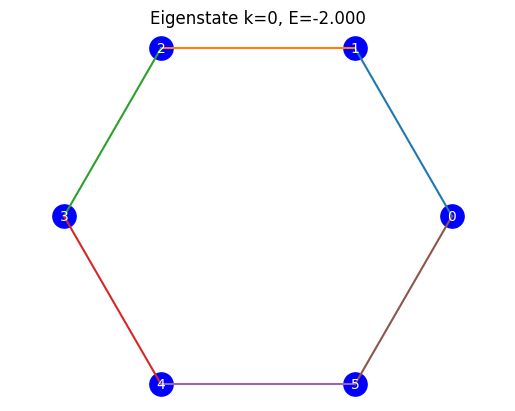

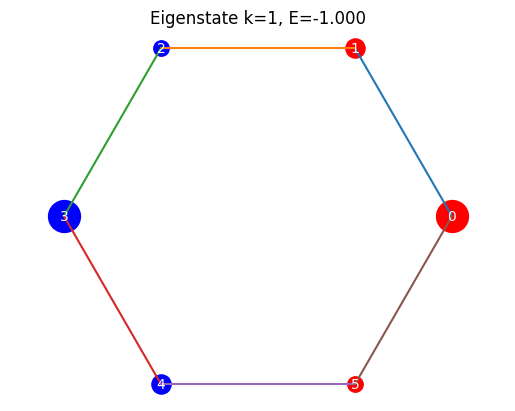

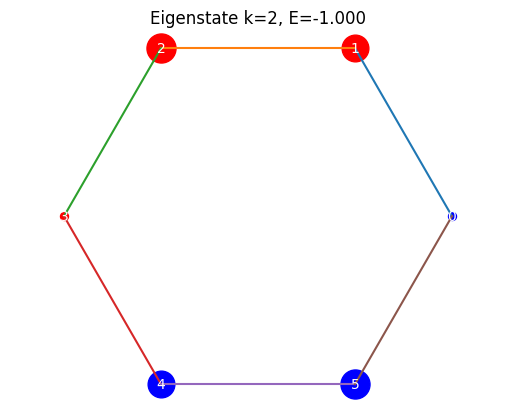

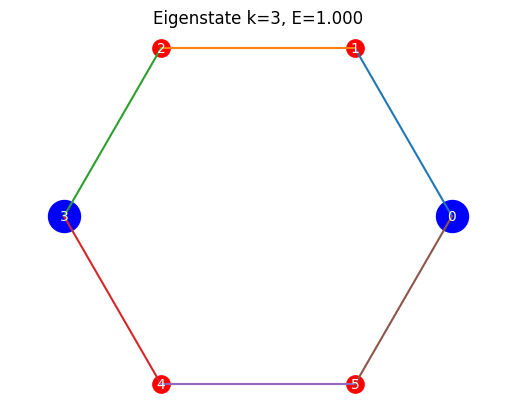

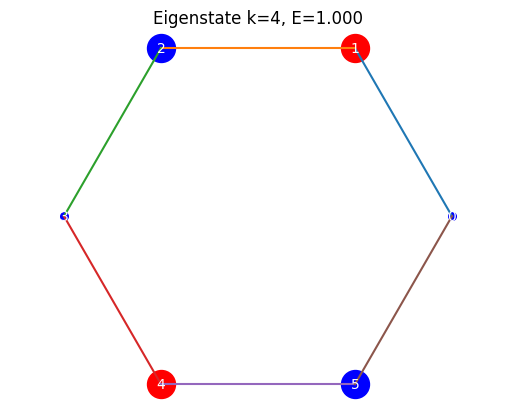

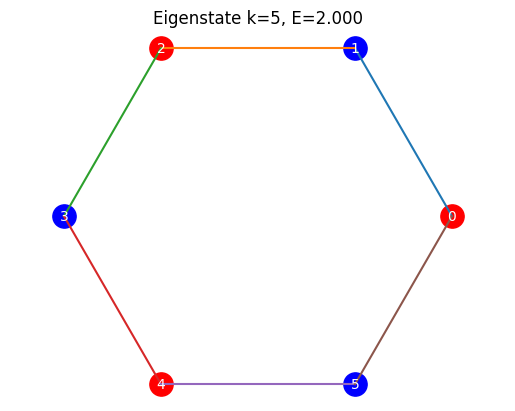

In [20]:
def plot_state(k):
    psi = eigenvectors[:, k]
    amp = np.abs(psi)
    sign = np.sign(psi + 1e-12)

    for i, j in fragment.edges:
        plt.plot([coords[i][0], coords[j][0]],
                 [coords[i][1], coords[j][1]])

    for i in range(fragment.n_sites):
        x, y = coords[i]
        size = 1500 * (amp[i]**2 + 0.02)
        color = "blue" if sign[i] >= 0 else "red"
        plt.scatter(x, y, s=size, color=color)
        plt.text(x, y, str(i), ha="center", va="center", color="white")

    plt.title(f"Eigenstate k={k}, E={energies[k]:.3f}")
    plt.axis("equal")
    plt.axis("off")
    plt.show()

for k in range(fragment.n_sites):
    plot_state(k)

future update to quantum circuit with qubits mapping 

In [ ]:
U = 2.0  # interaction strength
print("Next step: implement Hubbard model with U =", U)

Conceptually:

H = -t Σ (a†_i a_j + h.c.) + U Σ n_i↑ n_i↓

We will use Qiskit Nature.

In [ ]:
# pip install qiskit-nature if needed